# Vision Transformer (ViT) for Broken Stitch Detection

This notebook implements a Vision Transformer (ViT-B/16) model for the detection of broken stitches in garment images.

The model classifies images into two categories:

- **Broken Stitches**
- **Normal Stitches**

The notebook covers dataset preparation, ViT model development, transfer learning, model training, performance evaluation, error analysis, and model saving.

## 1. Google Drive Setup

Google Drive is mounted to provide access to the dataset and to save the trained ViT model.

This allows the notebook to:

- Access the training, validation, and test datasets
- Load required files from Google Drive
- Save the trained `.keras` model for future use



In [33]:
from google.colab import drive

drive.mount("/content/drive", force_remount=True)

print("Google Drive mounted successfully.")

Mounted at /content/drive
Google Drive mounted successfully.


## 2. Dataset Paths and Experimental Settings

The dataset paths and main experimental parameters are defined in this section. A fixed random seed is used to ensure reproducibility of the experiment.

The main settings include:

- **Image size:** 224 × 224 pixels
- **Batch size:** 32
- **Random seed:** 42
- **Number of classes:** 2
- **Classes:** Broken Stitches and Normal Stitches

The training, validation, and test dataset locations are also specified here.

In [34]:
import os
import random
import numpy as np

# -----------------------------
# Random seed
# -----------------------------
SEED = 42

random.seed(SEED)
np.random.seed(SEED)

# -----------------------------
# Dataset paths
# -----------------------------
dataset_path = "/content/drive/MyDrive/Dataset_GarmentDefectDetection/KaggleBrokenStitches/split_dataset"

train_path = os.path.join(dataset_path, "train")
validation_path = os.path.join(dataset_path, "validation")
test_path = os.path.join(dataset_path, "test")

# -----------------------------
# Image settings
# -----------------------------
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# -----------------------------
# Class names
# -----------------------------
CLASS_NAMES = [
    "BrokenStitches",
    "NormalStitches"
]

NUM_CLASSES = 2

# -----------------------------
# Check paths
# -----------------------------
print("Dataset path:", dataset_path)
print("Train path:", train_path)
print("Validation path:", validation_path)
print("Test path:", test_path)

print("\nChecking folders...")

print("Train exists:", os.path.exists(train_path))
print("Validation exists:", os.path.exists(validation_path))
print("Test exists:", os.path.exists(test_path))

print("\nClasses:", CLASS_NAMES)
print("Image size:", IMG_SIZE)
print("Batch size:", BATCH_SIZE)
print("Random seed:", SEED)

Dataset path: /content/drive/MyDrive/Dataset_GarmentDefectDetection/KaggleBrokenStitches/split_dataset
Train path: /content/drive/MyDrive/Dataset_GarmentDefectDetection/KaggleBrokenStitches/split_dataset/train
Validation path: /content/drive/MyDrive/Dataset_GarmentDefectDetection/KaggleBrokenStitches/split_dataset/validation
Test path: /content/drive/MyDrive/Dataset_GarmentDefectDetection/KaggleBrokenStitches/split_dataset/test

Checking folders...
Train exists: True
Validation exists: True
Test exists: True

Classes: ['BrokenStitches', 'NormalStitches']
Image size: (224, 224)
Batch size: 32
Random seed: 42


## 3. Dataset Path Verification

This section verifies that the training, validation, and test directories exist in Google Drive and that the expected class folders are available.

This check helps ensure that the dataset paths are correctly configured before loading the images.

In [35]:
for split in ["train", "validation", "test"]:

    split_path = os.path.join(dataset_path, split)

    print(f"\n{split}:")
    print("Path:", split_path)
    print("Exists:", os.path.exists(split_path))

    if os.path.exists(split_path):
        print("Folders:", os.listdir(split_path))


train:
Path: /content/drive/MyDrive/Dataset_GarmentDefectDetection/KaggleBrokenStitches/split_dataset/train
Exists: True
Folders: ['broken stitches', 'NormalStitches', 'brokenStitches', 'Normal Stitches']

validation:
Path: /content/drive/MyDrive/Dataset_GarmentDefectDetection/KaggleBrokenStitches/split_dataset/validation
Exists: True
Folders: ['Normal Stitches', 'broken stitches']

test:
Path: /content/drive/MyDrive/Dataset_GarmentDefectDetection/KaggleBrokenStitches/split_dataset/test
Exists: True
Folders: ['brokenStitches', 'Normal Stitches', 'broken stitches', 'NormalStitches']


## 4. TensorFlow and GPU Configuration

TensorFlow is imported and the available computing devices are checked.

GPU availability is important because it can significantly improve the training speed of the Vision Transformer model.

In [36]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)

gpus = tf.config.list_physical_devices("GPU")

print("GPU devices:", gpus)

if gpus:
    print("GPU is available.")
else:
    print("WARNING: GPU is NOT available.")

TensorFlow version: 2.20.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPU is available.


## 5. Install KerasHub

KerasHub is installed to provide access to the pre-trained Vision Transformer model used in this experiment.

The specified version is installed to maintain a consistent modelling environment.

In [37]:
!pip install -q keras-hub==0.26.0

## 6. Import Keras and KerasHub

The Keras and KerasHub libraries are imported for building and configuring the Vision Transformer model.

The installed library versions are also displayed to verify the software environment used for the experiment.

In [38]:
import keras
import keras_hub

print("Keras version:", keras.__version__)
print("KerasHub version:", keras_hub.__version__)

Keras version: 3.13.2
KerasHub version: 0.26.0


## 7. Dataset Distribution and Image Verification

This section examines the dataset structure and counts the available images in the training, validation, and test sets.

Checking the image distribution helps confirm that the dataset has been correctly divided between the two classification categories before model training.

In [39]:
import os

dataset_path = "/content/drive/MyDrive/Dataset_GarmentDefectDetection/KaggleBrokenStitches/split_dataset"

def count_images(folder):
    return len([
        f for f in os.listdir(folder)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ])


for split in ["train", "validation", "test"]:

    normal_folder = os.path.join(
        dataset_path, split, "Normal Stitches"
    )

    broken_folder = os.path.join(
        dataset_path, split, "broken stitches"
    )

    normal_count = count_images(normal_folder)
    broken_count = count_images(broken_folder)

    print(
        f"{split}: "
        f"Normal = {normal_count}, "
        f"Broken = {broken_count}, "
        f"Total = {normal_count + broken_count}"
    )

train: Normal = 984, Broken = 711, Total = 1695
validation: Normal = 209, Broken = 152, Total = 361
test: Normal = 210, Broken = 170, Total = 380


## 8. Dataset Preparation and Configuration

The training, validation, and test directories are configured for loading into TensorFlow.

The images are prepared using a fixed image size of 224 × 224 pixels and a batch size of 32. The class names are explicitly defined to ensure that the correct labels are assigned to the images.

In [40]:
import tensorflow as tf
import os

# ============================================================
# Dataset Paths
# ============================================================

dataset_path = "/content/drive/MyDrive/Dataset_GarmentDefectDetection/KaggleBrokenStitches/split_dataset"

train_path = os.path.join(dataset_path, "train")
validation_path = os.path.join(dataset_path, "validation")
test_path = os.path.join(dataset_path, "test")


# ============================================================
# Dataset Configuration
# ============================================================

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

# IMPORTANT:
# These names must exactly match the folder names in Google Drive
CLASS_NAMES = [
    "Normal Stitches",
    "broken stitches"
]


# ============================================================
# Load Training Dataset
# ============================================================

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_path,
    labels="inferred",
    label_mode="int",
    class_names=CLASS_NAMES,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)


# ============================================================
# Load Validation Dataset
# ============================================================

validation_ds = tf.keras.utils.image_dataset_from_directory(
    validation_path,
    labels="inferred",
    label_mode="int",
    class_names=CLASS_NAMES,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)


# ============================================================
# Load Test Dataset
# ============================================================

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_path,
    labels="inferred",
    label_mode="int",
    class_names=CLASS_NAMES,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)


# ============================================================
# Verify Dataset
# ============================================================

print("\nDatasets loaded successfully.")

print("Classes:", CLASS_NAMES)

print("\nClass Mapping:")
for index, class_name in enumerate(CLASS_NAMES):
    print(f"{index} -> {class_name}")

Found 1695 files belonging to 2 classes.
Found 361 files belonging to 2 classes.
Found 380 files belonging to 2 classes.

Datasets loaded successfully.
Classes: ['Normal Stitches', 'broken stitches']

Class Mapping:
0 -> Normal Stitches
1 -> broken stitches


## 9. Load Training, Validation and Test Datasets

The images are loaded from the training, validation, and test directories using TensorFlow's image dataset loader.

The datasets are configured with:

- Integer class labels
- Two classification classes
- Image size of **224 × 224 pixels**
- Batch size of **32**

The test dataset is kept separate from model training and is used only for final performance evaluation.

In [41]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_path,
    labels="inferred",
    label_mode="int",
    class_names=CLASS_NAMES,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

validation_ds = tf.keras.utils.image_dataset_from_directory(
    validation_path,
    labels="inferred",
    label_mode="int",
    class_names=CLASS_NAMES,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_path,
    labels="inferred",
    label_mode="int",
    class_names=CLASS_NAMES,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("\nDatasets loaded successfully.")
print("Classes:", CLASS_NAMES)

Found 1695 files belonging to 2 classes.
Found 361 files belonging to 2 classes.
Found 380 files belonging to 2 classes.

Datasets loaded successfully.
Classes: ['Normal Stitches', 'broken stitches']


## 10. Dataset Performance Optimization

TensorFlow dataset prefetching is enabled using `AUTOTUNE`.

Prefetching allows data preparation and model computation to overlap, improving the efficiency of training and evaluation.

In [42]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
validation_ds = validation_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

print("Dataset prefetching enabled.")

Dataset prefetching enabled.


## 11. Vision Transformer Model Development

A pre-trained Vision Transformer (ViT-B/16) model is created using KerasHub.

The pre-trained model provides learned visual features that can be adapted to the binary classification task of distinguishing between broken and normal stitches.

In [43]:
model = keras_hub.models.ViTImageClassifier.from_preset(
    "vit_base_patch16_224_imagenet",
    num_classes=NUM_CLASSES
)

print("ViT model created successfully.")

ViT model created successfully.


### 11.1 ViT Model Architecture

This section displays the architecture and parameter details of the Vision Transformer model.

The model summary provides information about the layers, output shapes, and total number of parameters used by the network.

In [44]:
model.summary()

Preprocessor: "vi_t_image_classifier_preprocessor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                                                  ┃                                   Config ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ vi_t_image_converter (ViTImageConverter)                      │                   Image size: (224, 224) │
└───────────────────────────────────────────────────────────────┴──────────────────────────────────────────┘

Model: "vi_t_image_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                                  ┃ Output Shape                       ┃             Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ images (InputLayer)                           │ (None, 224, 224, 3)                │                   0 │
├───────────────────────────────────────────────┼────────────────────────────────────┼─────────────────────┤
│ vi_t_backbone (ViTBackbone)                   │ (None, 197, 768)                   │          85,798,656 │
├───────────────────────────────────────────────┼────────────────────────────────────┼─────────────────────┤
│ get_item_2 (GetItem)                          │ (None, 768)                        │                   0 │
├───────────────────────────────────────────────┼────────────────────────────────────┼─────────────────────┤
│ output_dropout (Dropout)                      │ (None, 768)                        │                   0 │
├───────────────────────────────────────────────┼────────────────────────────────────┼─────────────────────┤
│ predictions (Dense)                           │ (None, 2)                          │               1,538 │
└───────────────────────────────────────────────┴────────────────────────────────────┴─────────────────────┘

 Total params: 85,800,194 (327.30 MB)

 Trainable params: 85,800,194 (327.30 MB)

 Non-trainable params: 0 (0.00 B)

### 11.2 Transfer Learning Configuration

The pre-trained ViT backbone is frozen so that its learned visual features remain unchanged during training.

Only the trainable classification component is adapted for the broken-stitch classification task. This approach reduces the number of parameters that need to be trained.

In [45]:
model.backbone.trainable = False

print("ViT backbone frozen.")
print("Backbone trainable:", model.backbone.trainable)

ViT backbone frozen.
Backbone trainable: False


### 11.3 Model Compilation

The Vision Transformer model is compiled using the AdamW optimizer and sparse categorical cross-entropy loss.

Accuracy is used as the main training metric to monitor the classification performance of the model.

In [46]:
model.compile(
    optimizer=keras.optimizers.AdamW(
        learning_rate=1e-4,
        weight_decay=1e-4
    ),
    loss=keras.losses.SparseCategoricalCrossentropy(
        from_logits=True
    ),
    metrics=["accuracy"]
)

print("ViT model compiled successfully.")

ViT model compiled successfully.


### 11.4 Training Callbacks

Early stopping and learning-rate reduction callbacks are configured to improve the training process.

- **EarlyStopping** monitors validation loss and restores the best model weights.
- **ReduceLROnPlateau** reduces the learning rate when validation loss stops improving.

These callbacks help the model train efficiently and reduce unnecessary training.

In [47]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-7
)

print("Training callbacks created.")

Training callbacks created.


## 12. ViT Model Training

The Vision Transformer model is trained using the training dataset and evaluated against the validation dataset during each epoch.

The training process is configured for a maximum of 12 epochs, with callbacks used to monitor validation performance.

In [48]:
history = model.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=12,
    callbacks=[
        early_stopping,
        reduce_lr
    ]
)

Epoch 1/12
53/53 ━━━━━━━━━━━━━━━━━━━━ 65s 674ms/step - accuracy: 0.5858 - loss: 0.7399 - val_accuracy: 0.6260 - val_loss: 0.6757 - learning_rate: 1.0000e-04
Epoch 2/12
53/53 ━━━━━━━━━━━━━━━━━━━━ 26s 480ms/step - accuracy: 0.6814 - loss: 0.5802 - val_accuracy: 0.7036 - val_loss: 0.5483 - learning_rate: 1.0000e-04
Epoch 3/12
53/53 ━━━━━━━━━━━━━━━━━━━━ 41s 488ms/step - accuracy: 0.7699 - loss: 0.4783 - val_accuracy: 0.7950 - val_loss: 0.4604 - learning_rate: 1.0000e-04
Epoch 4/12
53/53 ━━━━━━━━━━━━━━━━━━━━ 27s 512ms/step - accuracy: 0.8389 - loss: 0.4103 - val_accuracy: 0.8366 - val_loss: 0.4032 - learning_rate: 1.0000e-04
Epoch 5/12
53/53 ━━━━━━━━━━━━━━━━━━━━ 28s 528ms/step - accuracy: 0.8779 - loss: 0.3617 - val_accuracy: 0.8670 - val_loss: 0.3622 - learning_rate: 1.0000e-04
Epoch 6/12
53/53 ━━━━━━━━━━━━━━━━━━━━ 28s 536ms/step - accuracy: 0.8891 - loss: 0.3268 - val_accuracy: 0.8809 - val_loss: 0.3307 - learning_rate: 1.0000e-04
Epoch 7/12
53/53 ━━━━━━━━━━━━━━━━━━━━ 29s 548ms/step - acc

## 13. Training Performance Visualization

The training history is visualised using accuracy and loss curves.

These plots help assess the learning behaviour of the model and compare its performance on the training and validation datasets.

### 13.1 Training and Validation Accuracy

This graph compares the training accuracy and validation accuracy across the training epochs.

The curves provide an indication of how well the model learns the classification task and whether its performance generalises to the validation dataset.

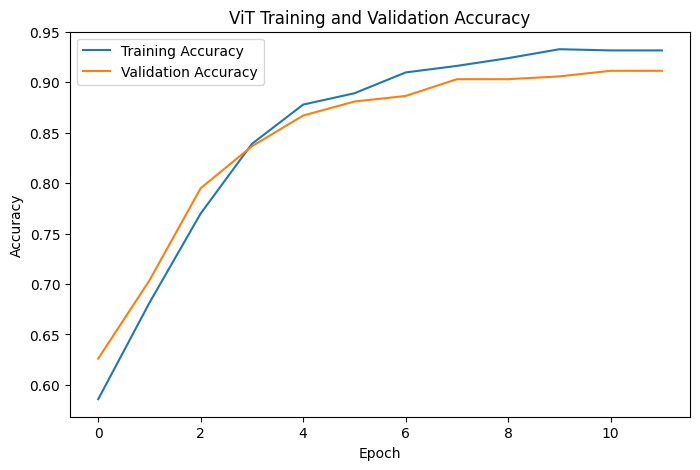

In [49]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ViT Training and Validation Accuracy")
plt.legend()
plt.show()

### 13.2 Training and Validation Loss

This graph compares the training loss and validation loss across the training epochs.

The loss curves help assess the learning behaviour of the model and identify possible differences between training and validation performance.

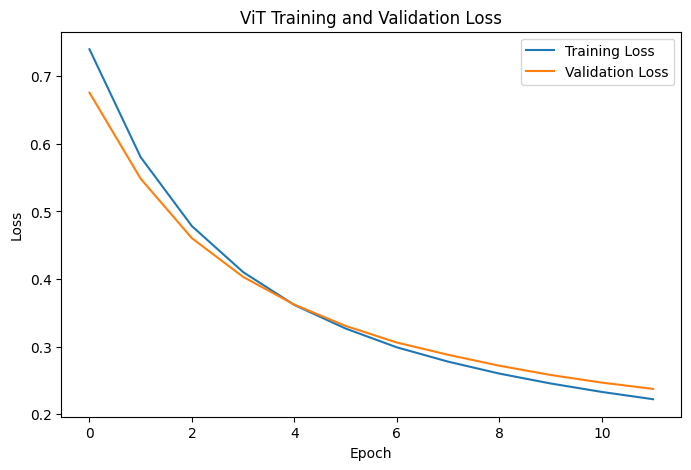

In [61]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ViT Training and Validation Loss")
plt.legend()
plt.show()

## 14. Model Evaluation on the Test Dataset

The trained Vision Transformer model is evaluated using the unseen test dataset.

Test loss and test accuracy are calculated to provide an initial measurement of the model's generalisation performance.

In [51]:
test_loss, test_accuracy = model.evaluate(
    test_ds,
    verbose=1
)

print("\nTest Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

12/12 ━━━━━━━━━━━━━━━━━━━━ 9s 783ms/step - accuracy: 0.9158 - loss: 0.2453

Test Loss: 0.24530842900276184
Test Accuracy: 0.9157894849777222


## 15. Test Set Prediction

Predictions are generated for all images in the test dataset.

The model outputs class probabilities using the softmax function, and the class with the highest probability is selected as the predicted class.

In [52]:
import numpy as np

y_true = []
y_probabilities = []

for images, labels in test_ds:

    logits = model.predict(
        images,
        verbose=0
    )

    probabilities = tf.nn.softmax(logits, axis=1)

    y_true.extend(labels.numpy())
    y_probabilities.extend(probabilities.numpy())

y_true = np.array(y_true)
y_probabilities = np.array(y_probabilities)

y_pred = np.argmax(
    y_probabilities,
    axis=1
)

print("Predictions generated successfully.")
print("Number of test images:", len(y_true))

Predictions generated successfully.
Number of test images: 380


## 16. Classification Performance Metrics

The model's classification performance is assessed using several standard metrics:

- **Accuracy** – overall proportion of correctly classified images
- **Precision** – proportion of predicted positive cases that are correct
- **Recall** – proportion of actual positive cases correctly identified
- **F1-score** – balance between precision and recall

These metrics provide a broader assessment of model performance than accuracy alone.

In [53]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy = accuracy_score(
    y_true,
    y_pred
)

precision = precision_score(
    y_true,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_true,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_true,
    y_pred,
    zero_division=0
)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.9157894736842105
Precision: 0.9207317073170732
Recall   : 0.888235294117647
F1 Score : 0.9041916167664671


## 17. Confusion Matrix

A confusion matrix is generated to show the number of correctly and incorrectly classified images for each class.

It provides a visual representation of the model's classification performance for broken and normal stitches.

Confusion Matrix:
[[197  13]
 [ 19 151]]


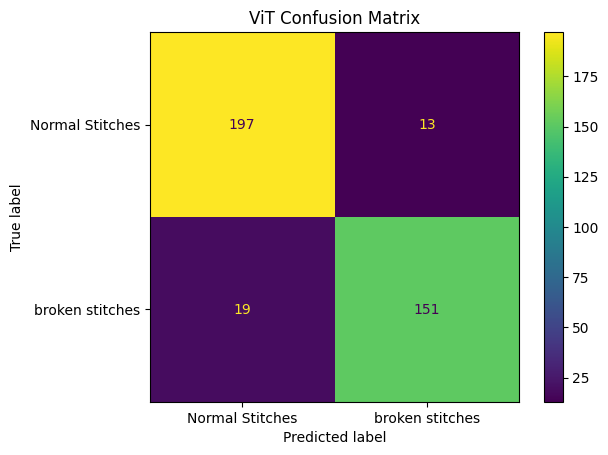

In [54]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(
    y_true,
    y_pred
)

print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=CLASS_NAMES
)

disp.plot()
plt.title("ViT Confusion Matrix")
plt.show()

## 18. Broken Stitch Detection Error Analysis

For the specific broken-stitch detection task, **BrokenStitches is treated as the positive class**.

The following error measures are calculated:

- **False Positive Rate (FPR):** proportion of normal-stitch images incorrectly classified as broken stitches.
- **False Negative Rate (FNR):** proportion of broken-stitch images incorrectly classified as normal stitches.

This class definition ensures that the error analysis focuses specifically on the detection of broken stitches.

In [55]:
# Correct FPR and FNR for Broken Stitch Detection
# BrokenStitches = positive class

from sklearn.metrics import confusion_matrix

# Convert class labels:
# BrokenStitches (0) -> Positive (1)
# NormalStitches (1) -> Negative (0)

y_true_broken = (y_true == 0).astype(int)
y_pred_broken = (y_pred == 0).astype(int)

cm_broken = confusion_matrix(
    y_true_broken,
    y_pred_broken
)

tn, fp, fn, tp = cm_broken.ravel()

fpr_broken = fp / (fp + tn) if (fp + tn) > 0 else 0
fnr_broken = fn / (fn + tp) if (fn + tp) > 0 else 0

print("Confusion Matrix (Broken Stitch = Positive):")
print(cm_broken)

print("\nTrue Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives  :", tp)

print("\nCorrect FPR:", fpr_broken)
print("Correct FNR:", fnr_broken)

print("\nCorrect FPR (%):", fpr_broken * 100)
print("Correct FNR (%):", fnr_broken * 100)

Confusion Matrix (Broken Stitch = Positive):
[[151  19]
 [ 13 197]]

True Negatives : 151
False Positives: 19
False Negatives: 13
True Positives  : 197

Correct FPR: 0.11176470588235295
Correct FNR: 0.06190476190476191

Correct FPR (%): 11.176470588235295
Correct FNR (%): 6.190476190476191


## 19. Classification Report

A detailed classification report is generated for both classes.

The report provides precision, recall, and F1-score for **Normal Stitches** and **Broken Stitches**, allowing the performance of each class to be assessed separately.

In [56]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_true,
        y_pred,
        target_names=CLASS_NAMES,
        digits=4
    )
)

                 precision    recall  f1-score   support

Normal Stitches     0.9120    0.9381    0.9249       210
broken stitches     0.9207    0.8882    0.9042       170

       accuracy                         0.9158       380
      macro avg     0.9164    0.9132    0.9145       380
   weighted avg     0.9159    0.9158    0.9156       380



## 20. Inference Time Evaluation

The inference time of the trained ViT model is measured using a batch of test images.

The average inference time per image is calculated to assess how quickly the model can generate predictions.

In [57]:
import time

# Take one batch for timing
images, labels = next(iter(test_ds))

# Warm-up
_ = model.predict(images, verbose=0)

start_time = time.time()

_ = model.predict(images, verbose=0)

end_time = time.time()

batch_time = end_time - start_time

num_images = images.shape[0]

average_inference_time = batch_time / num_images

print("Images in batch:", num_images)
print("Batch inference time:", batch_time, "seconds")
print("Average inference time per image:",
      average_inference_time, "seconds")

Images in batch: 32
Batch inference time: 0.8247401714324951 seconds
Average inference time per image: 0.025773130357265472 seconds


## 21. Save the Trained ViT Model

The trained Vision Transformer model is saved in Keras `.keras` format to Google Drive.

Saving the model allows it to be loaded and reused later without repeating the training process.

In [58]:
# CELL 24 — Save the trained ViT model

vit_model_path = "/content/drive/MyDrive/Dataset_GarmentDefectDetection/KaggleBrokenStitches/ViT_Model.keras"

model.save(vit_model_path)

print("ViT model saved successfully.")
print("Location:", vit_model_path)

ViT model saved successfully.
Location: /content/drive/MyDrive/Dataset_GarmentDefectDetection/KaggleBrokenStitches/ViT_Model.keras


## 22. Final Broken Stitch Detection Metrics

The final performance metrics are calculated specifically for the broken-stitch detection task.

In this analysis, **BrokenStitches is treated as the positive class**. Accuracy, precision, recall, F1-score, FPR, and FNR are reported to provide a focused evaluation of the model's ability to detect broken stitches.

In [59]:
# Metrics specifically for Broken Stitch detection
# BrokenStitches = positive class

from sklearn.metrics import precision_score, recall_score, f1_score

precision_broken = precision_score(
    y_true_broken,
    y_pred_broken,
    zero_division=0
)

recall_broken = recall_score(
    y_true_broken,
    y_pred_broken,
    zero_division=0
)

f1_broken = f1_score(
    y_true_broken,
    y_pred_broken,
    zero_division=0
)

accuracy_broken = np.mean(
    y_true_broken == y_pred_broken
)

print("Broken Stitch Detection Metrics")
print("--------------------------------")
print("Accuracy :", accuracy_broken)
print("Precision:", precision_broken)
print("Recall   :", recall_broken)
print("F1 Score :", f1_broken)

print("\nPercentages")
print("Accuracy :", accuracy_broken * 100, "%")
print("Precision:", precision_broken * 100, "%")
print("Recall   :", recall_broken * 100, "%")
print("F1 Score :", f1_broken * 100, "%")

Broken Stitch Detection Metrics
--------------------------------
Accuracy : 0.9157894736842105
Precision: 0.9120370370370371
Recall   : 0.9380952380952381
F1 Score : 0.9248826291079812

Percentages
Accuracy : 91.57894736842105 %
Precision: 91.20370370370371 %
Recall   : 93.80952380952381 %
F1 Score : 92.48826291079813 %


## 23. Reload the Saved ViT Model

The saved ViT model is loaded from Google Drive to verify that the trained model has been successfully saved and can be restored for future use.

This allows the trained model to be reused without retraining it from the beginning.

In [62]:
import keras

vit_model_path = "/content/drive/MyDrive/Dataset_GarmentDefectDetection/KaggleBrokenStitches/ViT_Model.keras"

loaded_vit_model = keras.models.load_model(vit_model_path)

print("ViT model loaded successfully!")

ViT model loaded successfully!
